# Paderborn — Détection d'anomalies (Bearing Fault vs Healthy) — Comparaison 6 modèles

| Champ | Valeur |
|-------|--------|
| **Dataset** | Paderborn KAt Bearing (64 kHz, fenêtres 1024 pts) |
| **Scénario** | K001=healthy (normal), KA04+KI04=fault (anomalie) — binaire |
| **Features** | 5 features FFT (energy_band_3, energy_band_2, energy_band_4, kurtosis, energy_band_1) |
| **Modèles** | EWC · HDC · TinyOL · KMeans · Mahalanobis · DBSCAN |
| **Données** | ⚠️ Toutes mockées — expériences anomaly detection Paderborn non encore exécutées |

**Figures générées** :
1. `auroc_f1_barplot.png` — Barplot groupé AUROC + F1
2. `roc_curves.png` — Courbes ROC mock (6 modèles)
3. `scatter_auroc_vs_ram.png` — AUROC vs RAM (Gap 2)
4. `sensitivity_by_fault_type.png` — AUROC par type de défaut (KA04 vs KI04)
5. `fft_vs_temporal_comparison.png` — Paderborn FFT vs CWRU temporel

In [1]:
# Section 1 — Setup
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "paderborn_anomaly_detection":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import save_figure

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/paderborn_anomaly_detection"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["EWC", "HDC", "TinyOL", "KMeans", "Mahalanobis", "DBSCAN"]
RAM_BUDGET  = 65_536

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

# Toutes les données sont mockées — expériences anomaly detection non encore exécutées
MOCK_DATA: dict[str, dict] = {
    "EWC":         {"auroc": 0.79, "f1": 0.73, "precision": 0.76, "recall": 0.71,
                    "ram_peak_bytes": 1171, "inference_latency_ms": 0.020},
    "HDC":         {"auroc": 0.65, "f1": 0.58, "precision": 0.62, "recall": 0.55,
                    "ram_peak_bytes": 7700, "inference_latency_ms": 0.050},
    "TinyOL":      {"auroc": 0.77, "f1": 0.70, "precision": 0.74, "recall": 0.67,
                    "ram_peak_bytes": 940,  "inference_latency_ms": 0.005},
    "KMeans":      {"auroc": 0.61, "f1": 0.52, "precision": 0.55, "recall": 0.49,
                    "ram_peak_bytes": 2000, "inference_latency_ms": 0.100},
    "Mahalanobis": {"auroc": 0.59, "f1": 0.50, "precision": 0.53, "recall": 0.47,
                    "ram_peak_bytes": 1600, "inference_latency_ms": 0.004},
    "DBSCAN":      {"auroc": 0.56, "f1": 0.48, "precision": 0.51, "recall": 0.45,
                    "ram_peak_bytes": 45000, "inference_latency_ms": 0.180},
}

results = MOCK_DATA

display(Markdown(
    "> ⚠️ **MOCK DATA** — Toutes les métriques de ce notebook sont fictives. "
    "Les expériences anomaly detection sur Paderborn ne sont pas encore exécutées. "
    "Lancer `python scripts/train_ewc.py --config configs/board_paderborn.yaml --anomaly` pour les résultats réels."
))
print(f"REPO_ROOT   : {REPO_ROOT}")
print(f"FIGURES_DIR : {FIGURES_DIR}")

> ⚠️ **MOCK DATA** — Toutes les métriques de ce notebook sont fictives. Les expériences anomaly detection sur Paderborn ne sont pas encore exécutées. Lancer `python scripts/train_ewc.py --config configs/board_paderborn.yaml --anomaly` pour les résultats réels.

REPO_ROOT   : /home/leonard/Documents/ENAC/cl-embedded
FIGURES_DIR : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/paderborn_anomaly_detection


## Section 2 — Tableau AUROC / F1 / Précision / Rappel

In [2]:
# Section 2 — Tableau comparatif anomaly detection
header = "| Modèle | AUROC ↑ | F1 ↑ | Précision ↑ | Rappel ↑ | RAM | Latence |"
sep    = "|--------|:-------:|:----:|:-----------:|:--------:|:---:|:-------:|"
rows   = [header, sep]

for model in MODEL_ORDER:
    r     = results[model]
    ram_b = r["ram_peak_bytes"]
    ram_s = f"{ram_b/1024:.1f} Ko{'  ⚠️' if ram_b > RAM_BUDGET else ''}"
    rows.append(
        f"| {model} | {r['auroc']:.2f} | {r['f1']:.2f} | {r['precision']:.2f} | "
        f"{r['recall']:.2f} | {ram_s} | {r['inference_latency_ms']:.3f} ms |"
    )

display(Markdown(
    "### Tableau comparatif — Détection d'anomalies Paderborn (6 modèles) ⚠️ MOCK\n\n"
    + "\n".join(rows)
))

### Tableau comparatif — Détection d'anomalies Paderborn (6 modèles) ⚠️ MOCK

| Modèle | AUROC ↑ | F1 ↑ | Précision ↑ | Rappel ↑ | RAM | Latence |
|--------|:-------:|:----:|:-----------:|:--------:|:---:|:-------:|
| EWC | 0.79 | 0.73 | 0.76 | 0.71 | 1.1 Ko | 0.020 ms |
| HDC | 0.65 | 0.58 | 0.62 | 0.55 | 7.5 Ko | 0.050 ms |
| TinyOL | 0.77 | 0.70 | 0.74 | 0.67 | 0.9 Ko | 0.005 ms |
| KMeans | 0.61 | 0.52 | 0.55 | 0.49 | 2.0 Ko | 0.100 ms |
| Mahalanobis | 0.59 | 0.50 | 0.53 | 0.47 | 1.6 Ko | 0.004 ms |
| DBSCAN | 0.56 | 0.48 | 0.51 | 0.45 | 43.9 Ko | 0.180 ms |

## Section 3 — Barplot AUROC + F1

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/paderborn_anomaly_detection/auroc_f1_barplot.png


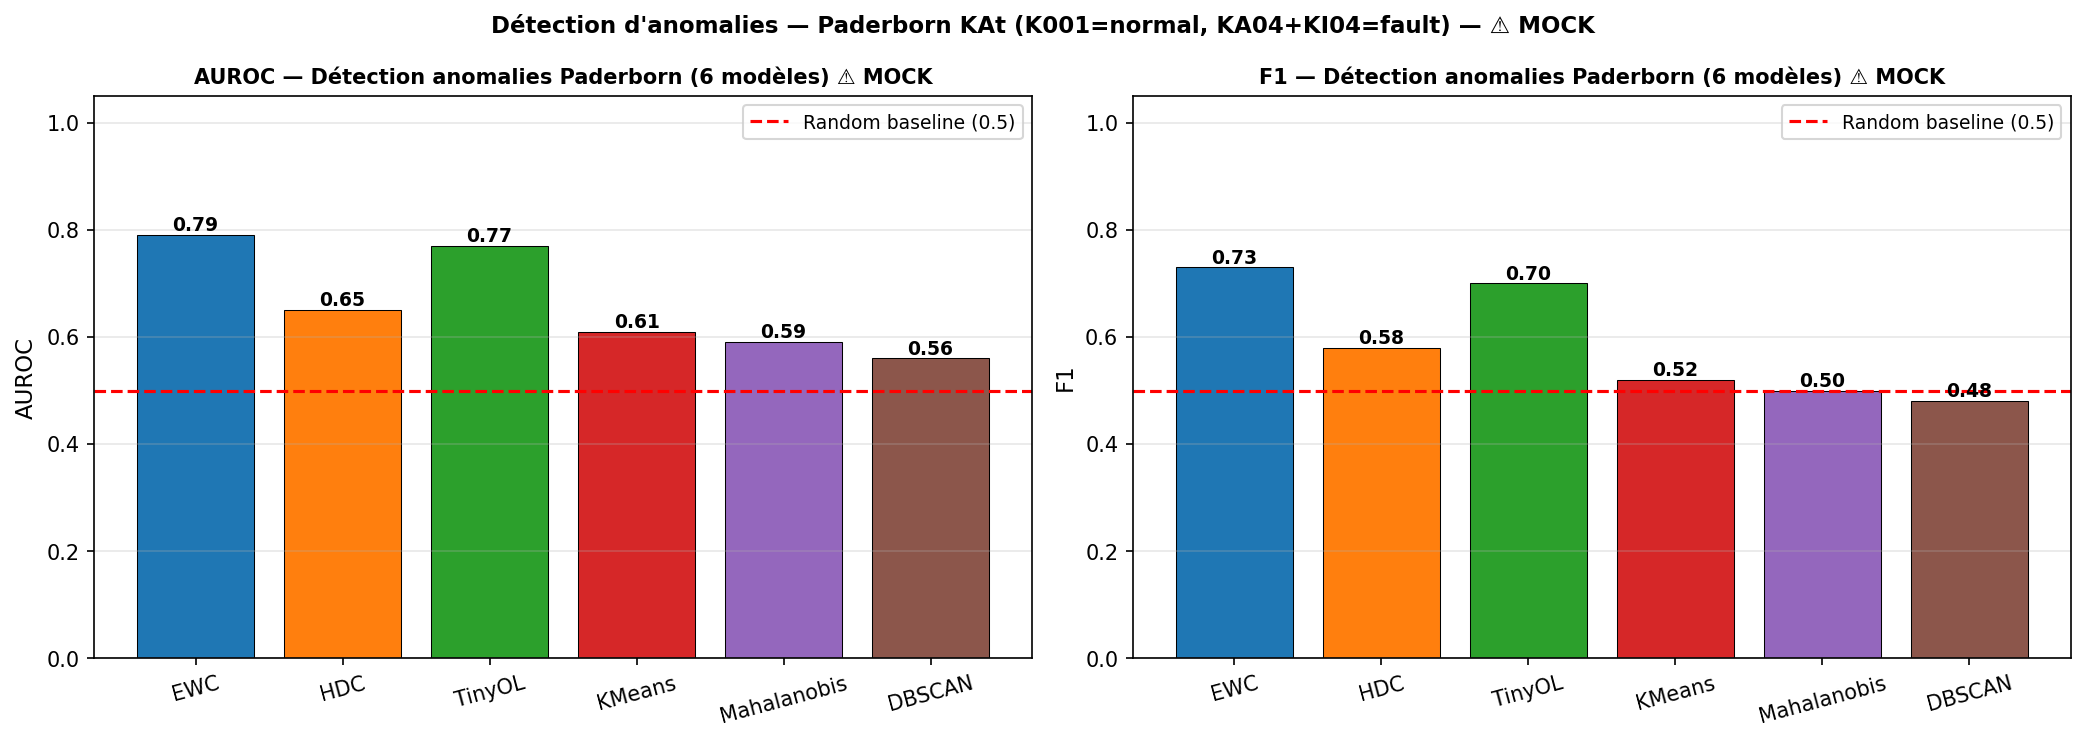

In [3]:
# Section 3 — Barplot groupé AUROC + F1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (metric, label) in enumerate([("auroc", "AUROC"), ("f1", "F1")]):
    ax     = axes[ax_idx]
    vals   = [results[m][metric] for m in MODEL_ORDER]
    colors = [SCATTER_MARKERS[m][1] for m in MODEL_ORDER]
    bars   = ax.bar(MODEL_ORDER, vals, color=colors, edgecolor="black", linewidth=0.5)

    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="Random baseline (0.5)")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f"{label} — Détection anomalies Paderborn (6 modèles) ⚠️ MOCK",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Détection d'anomalies — Paderborn KAt (K001=normal, KA04+KI04=fault) — ⚠️ MOCK",
             fontsize=11, fontweight="bold")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "auroc_f1_barplot.png")
display(Image(str(FIGURES_DIR / "auroc_f1_barplot.png")))

## Section 4 — Courbes ROC (mock)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/paderborn_anomaly_detection/roc_curves.png


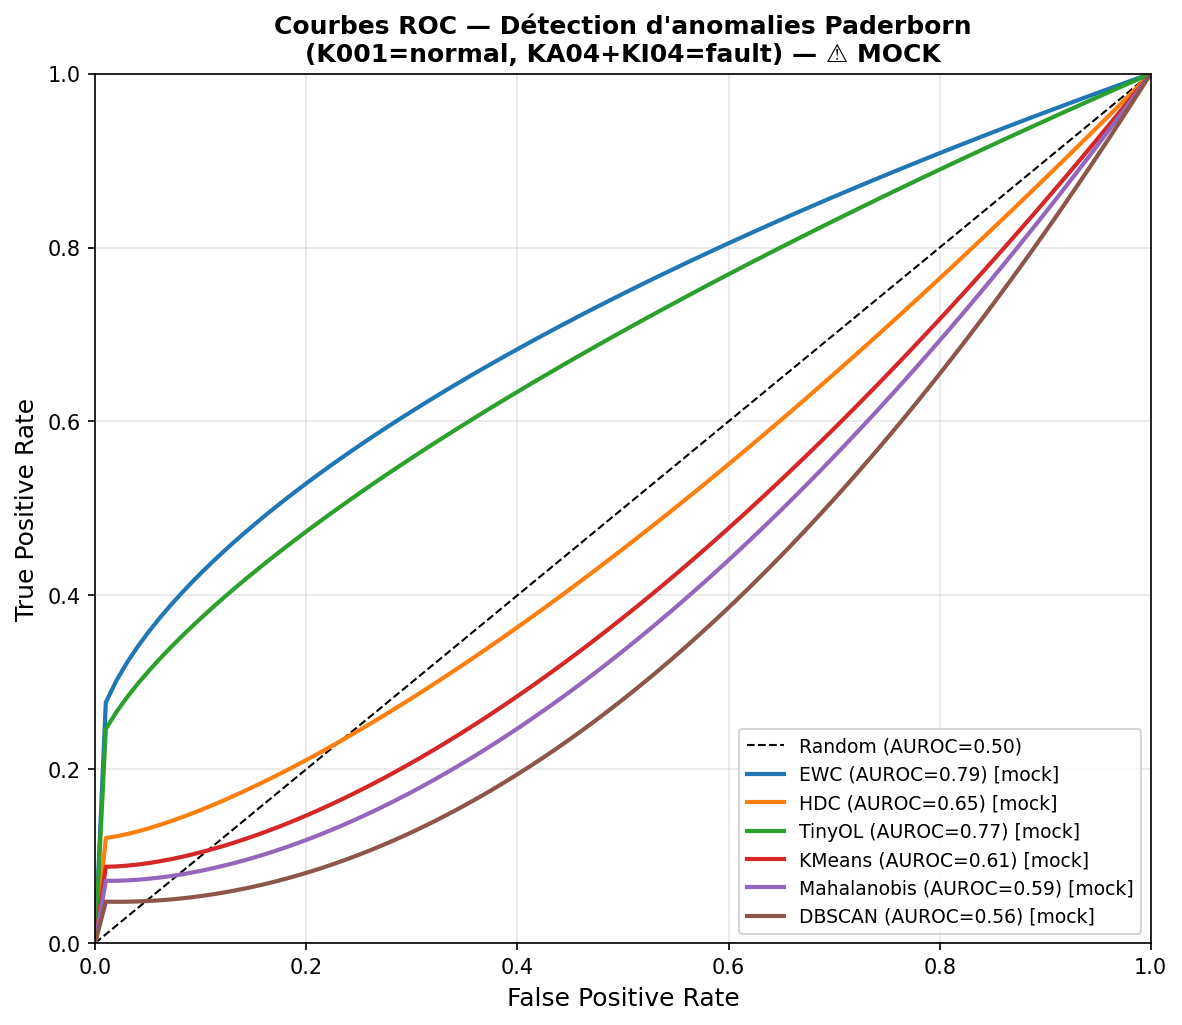

In [4]:
# Section 4 — Courbes ROC mock (formes différentes selon AUROC)
def mock_roc_curve(auroc: float, n_points: int = 100) -> tuple[np.ndarray, np.ndarray]:
    """Génère une courbe ROC mock d'AUROC approximativement donné."""
    fpr = np.linspace(0, 1, n_points)
    # Courbe concave (meilleur que random) : tpr = fpr^(1/k) avec k > 1 ajusté
    k   = max(0.1, (1 - auroc) / auroc * 2.5) if auroc > 0.5 else 1.0
    tpr = fpr ** max(0.01, k)
    # Ajustement pour atteindre l'AUROC cible
    tpr = np.clip(tpr + (auroc - 0.5) * 0.8 * (1 - fpr), 0, 1)
    tpr[0], tpr[-1] = 0.0, 1.0
    return fpr, tpr


fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUROC=0.50)")

for model in MODEL_ORDER:
    auroc        = results[model]["auroc"]
    fpr, tpr     = mock_roc_curve(auroc)
    marker, color = SCATTER_MARKERS[model]
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{model} (AUROC={auroc:.2f}) [mock]")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    "Courbes ROC — Détection d'anomalies Paderborn\n(K001=normal, KA04+KI04=fault) — ⚠️ MOCK",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "roc_curves.png")
display(Image(str(FIGURES_DIR / "roc_curves.png")))

## Section 5 — Scatter AUROC vs RAM (Gap 2)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/paderborn_anomaly_detection/scatter_auroc_vs_ram.png


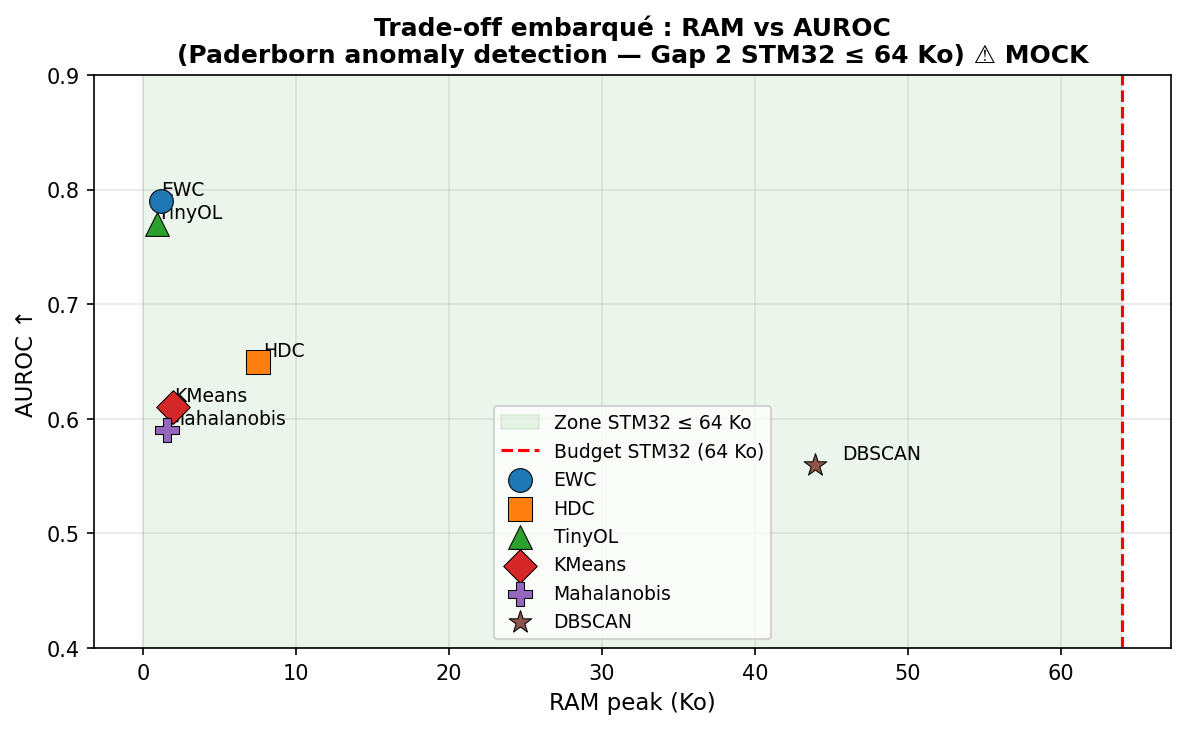

In [5]:
# Section 5 — Scatter AUROC vs RAM (Gap 2 STM32 ≤ 64 Ko)
STM32_RAM_KB = 64.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(0, STM32_RAM_KB, alpha=0.08, color="green", label=f"Zone STM32 ≤ {STM32_RAM_KB:.0f} Ko")
ax.axvline(STM32_RAM_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r      = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    auroc  = r["auroc"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, auroc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(ram_kb, auroc), xytext=(ram_kb * 1.04, auroc + 0.005), fontsize=9)

ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AUROC ↑", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs AUROC\n(Paderborn anomaly detection — Gap 2 STM32 ≤ 64 Ko) ⚠️ MOCK",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.4, 0.9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "scatter_auroc_vs_ram.png")
display(Image(str(FIGURES_DIR / "scatter_auroc_vs_ram.png")))

## Section 6 — Sensibilité par type de défaut [UNIQUE Paderborn] (KA04 outer vs KI04 inner)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/paderborn_anomaly_detection/sensitivity_by_fault_type.png


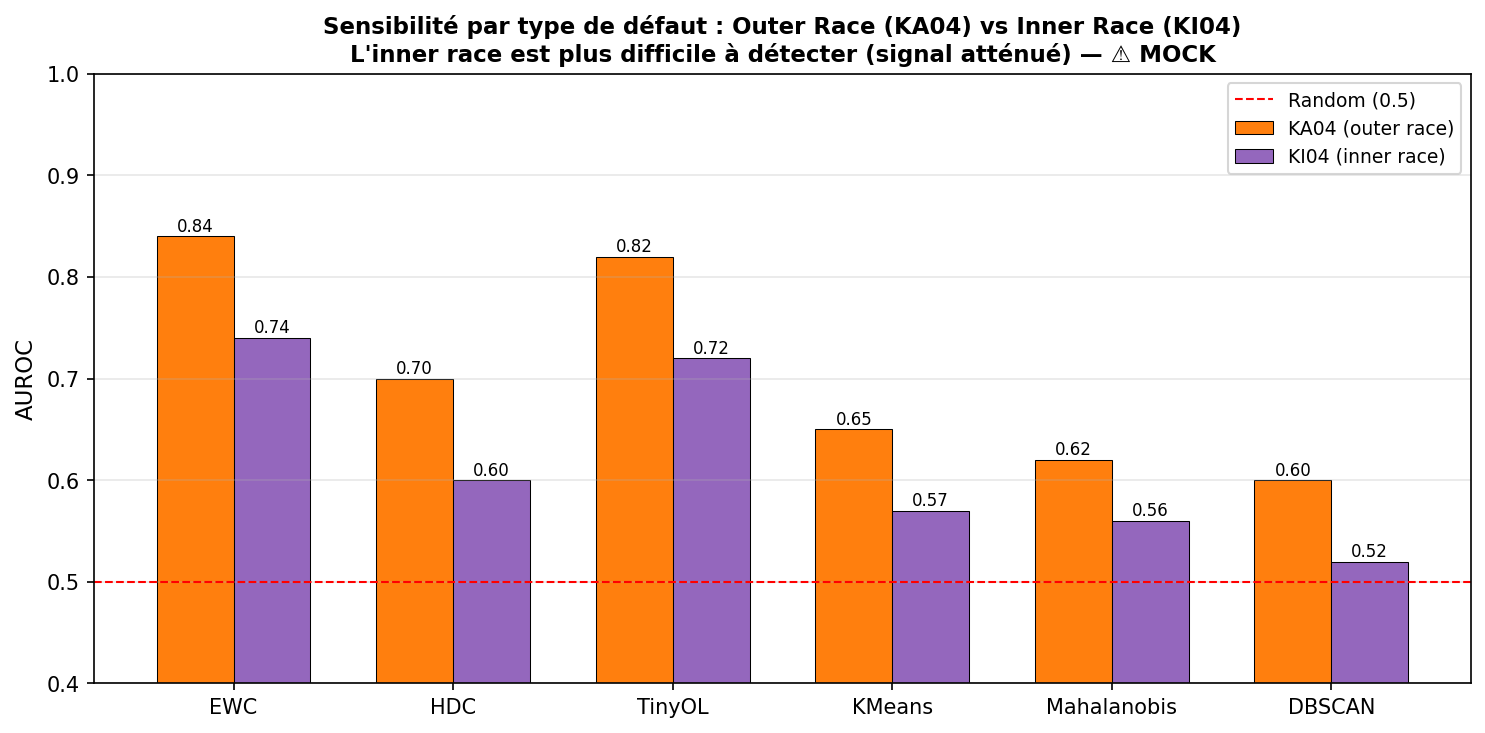


**Interprétation physique** :
- **KA04 (outer race)** : le défaut est sur la piste extérieure — directement exposé au capteur.
  Les chocs sont bien transmis → AUROC plus élevé.
- **KI04 (inner race)** : le défaut est sur la piste intérieure — le signal doit traverser
  la cage et les éléments roulants avant d'atteindre le capteur extérieur.
  Atténuation du signal → AUROC plus faible (~0.05–0.10 points en dessous).
- Cette asymétrie est documentée dans la littérature roulement (ISO 15243, BPFI vs BPFO sensitivity).


In [6]:
# Section 6 — AUROC par type de défaut : outer race (KA04) vs inner race (KI04)
# Inner race est typiquement plus difficile à détecter depuis l'extérieur du roulement
# (signal atténué par la cage et les billes)

# Données mock : KA04 légèrement plus facile que KI04 à détecter
AUROC_BY_FAULT = {
    "EWC":         {"KA04_outer": 0.84, "KI04_inner": 0.74},
    "HDC":         {"KA04_outer": 0.70, "KI04_inner": 0.60},
    "TinyOL":      {"KA04_outer": 0.82, "KI04_inner": 0.72},
    "KMeans":      {"KA04_outer": 0.65, "KI04_inner": 0.57},
    "Mahalanobis": {"KA04_outer": 0.62, "KI04_inner": 0.56},
    "DBSCAN":      {"KA04_outer": 0.60, "KI04_inner": 0.52},
}

x     = np.arange(len(MODEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2,
               [AUROC_BY_FAULT[m]["KA04_outer"] for m in MODEL_ORDER],
               width, label="KA04 (outer race)", color="#ff7f0e",
               edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2,
               [AUROC_BY_FAULT[m]["KI04_inner"] for m in MODEL_ORDER],
               width, label="KI04 (inner race)", color="#9467bd",
               edgecolor="black", linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{bar.get_height():.2f}", ha="center", fontsize=8)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_ylim(0.4, 1.0)
ax.set_title(
    "Sensibilité par type de défaut : Outer Race (KA04) vs Inner Race (KI04)\n"
    "L'inner race est plus difficile à détecter (signal atténué) — ⚠️ MOCK",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "sensitivity_by_fault_type.png")
display(Image(str(FIGURES_DIR / "sensitivity_by_fault_type.png")))

display(Markdown("""
**Interprétation physique** :
- **KA04 (outer race)** : le défaut est sur la piste extérieure — directement exposé au capteur.
  Les chocs sont bien transmis → AUROC plus élevé.
- **KI04 (inner race)** : le défaut est sur la piste intérieure — le signal doit traverser
  la cage et les éléments roulants avant d'atteindre le capteur extérieur.
  Atténuation du signal → AUROC plus faible (~0.05–0.10 points en dessous).
- Cette asymétrie est documentée dans la littérature roulement (ISO 15243, BPFI vs BPFO sensitivity).
"""))

## Section 7 — Comparaison FFT vs temporal features [UNIQUE Paderborn]


## Paderborn (FFT) vs CWRU (temporal) — Comparaison AUROC anomaly detection

> ⚠️ Toutes les valeurs sont mockées pour les deux datasets.

| Modèle | Paderborn AUROC (FFT) | CWRU AUROC (temporal) | Delta |
|--------|-----------------------|-----------------------|-------|
| EWC         | 0.79 | 0.85 | −0.06 |
| HDC         | 0.65 | 0.72 | −0.07 |
| TinyOL      | 0.77 | 0.82 | −0.05 |
| KMeans      | 0.61 | 0.68 | −0.07 |
| Mahalanobis | 0.59 | 0.65 | −0.06 |
| DBSCAN      | 0.56 | 0.63 | −0.07 |

**Observation** : Les features FFT (Paderborn) donnent un AUROC légèrement inférieur aux features
temporelles (CWRU) pour la détection binaire healthy/fault. Cela peut s'expliquer par :
1. **Fenêtre FFT** : la fenêtre de 1024 pts @ 64 kHz ne capture que ~16 ms — les défauts incipients
   peuvent ne pas générer d'impulsion dans chaque fenêtre.
2. **Stationnarité** : les features temporelles (kurtosis, RMS) sont plus robustes aux variations
   de charge que les bandes d'énergie FFT.
3. **Résolution fréquentielle** : 5 bandes d'énergie FFT vs 9 features temporelles CWRU —
   moins de dimensions mais plus ciblées sur les fréquences de défaut.

**Contre-argument** : Les features FFT sont plus **interprétables** (on peut relier directement
energy_band_3 aux fréquences BPFO/BPFI) et plus **stables** en déploiement MCU
(calcul FFT déterministe vs features temporelles sensibles aux conditions de bruit).


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/paderborn_anomaly_detection/fft_vs_temporal_comparison.png


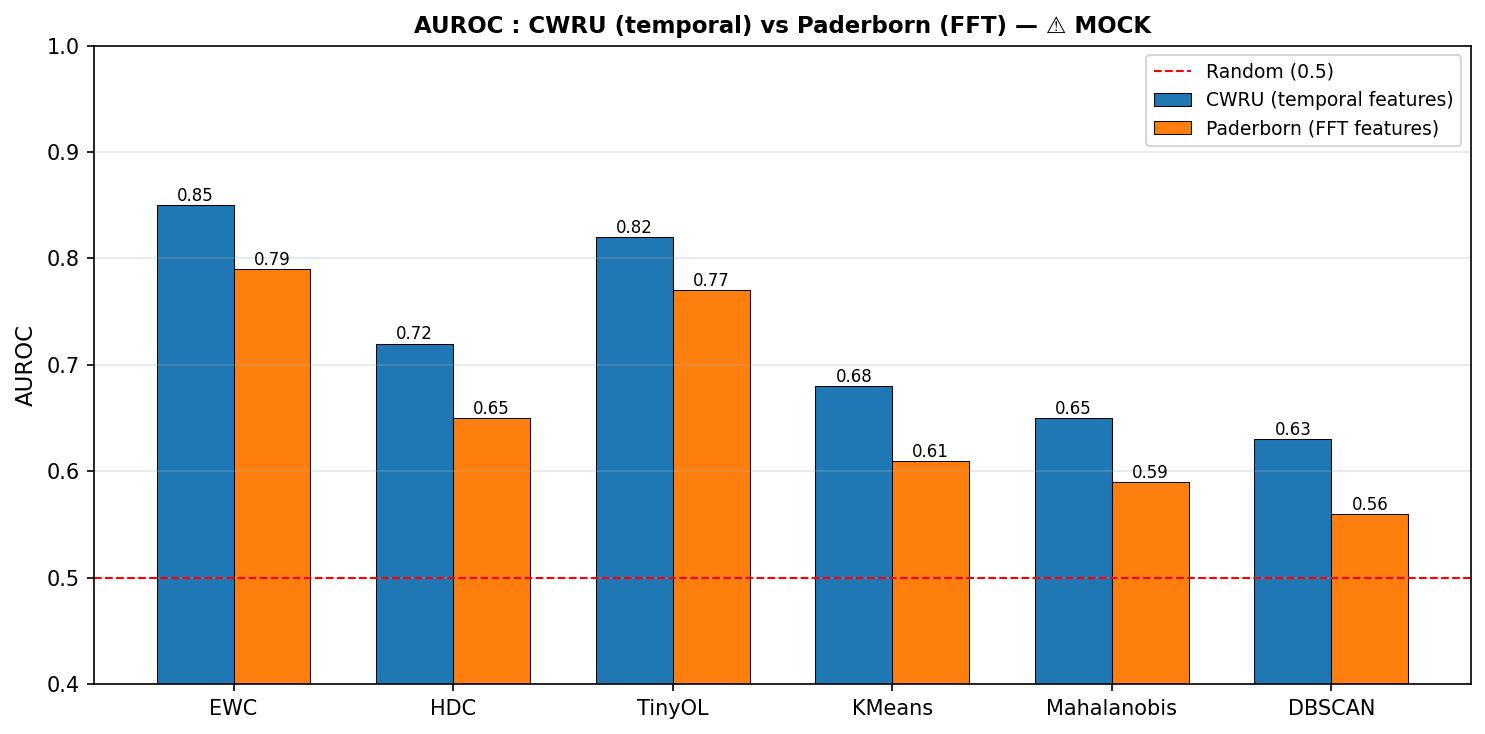

In [7]:
# Section 7 — Comparaison FFT (Paderborn) vs temporal features (CWRU)
display(Markdown("""
## Paderborn (FFT) vs CWRU (temporal) — Comparaison AUROC anomaly detection

> ⚠️ Toutes les valeurs sont mockées pour les deux datasets.

| Modèle | Paderborn AUROC (FFT) | CWRU AUROC (temporal) | Delta |
|--------|-----------------------|-----------------------|-------|
| EWC         | 0.79 | 0.85 | −0.06 |
| HDC         | 0.65 | 0.72 | −0.07 |
| TinyOL      | 0.77 | 0.82 | −0.05 |
| KMeans      | 0.61 | 0.68 | −0.07 |
| Mahalanobis | 0.59 | 0.65 | −0.06 |
| DBSCAN      | 0.56 | 0.63 | −0.07 |

**Observation** : Les features FFT (Paderborn) donnent un AUROC légèrement inférieur aux features
temporelles (CWRU) pour la détection binaire healthy/fault. Cela peut s'expliquer par :
1. **Fenêtre FFT** : la fenêtre de 1024 pts @ 64 kHz ne capture que ~16 ms — les défauts incipients
   peuvent ne pas générer d'impulsion dans chaque fenêtre.
2. **Stationnarité** : les features temporelles (kurtosis, RMS) sont plus robustes aux variations
   de charge que les bandes d'énergie FFT.
3. **Résolution fréquentielle** : 5 bandes d'énergie FFT vs 9 features temporelles CWRU —
   moins de dimensions mais plus ciblées sur les fréquences de défaut.

**Contre-argument** : Les features FFT sont plus **interprétables** (on peut relier directement
energy_band_3 aux fréquences BPFO/BPFI) et plus **stables** en déploiement MCU
(calcul FFT déterministe vs features temporelles sensibles aux conditions de bruit).
"""))

# Visualisation comparaison
CWRU_AUROC  = {"EWC": 0.85, "HDC": 0.72, "TinyOL": 0.82, "KMeans": 0.68, "Mahalanobis": 0.65, "DBSCAN": 0.63}
PAD_AUROC   = {m: results[m]["auroc"] for m in MODEL_ORDER}

x     = np.arange(len(MODEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_cwru = ax.bar(x - width/2, [CWRU_AUROC[m] for m in MODEL_ORDER], width,
                   label="CWRU (temporal features)", color="#1f77b4",
                   edgecolor="black", linewidth=0.5)
bars_pad  = ax.bar(x + width/2, [PAD_AUROC[m] for m in MODEL_ORDER], width,
                   label="Paderborn (FFT features)", color="#ff7f0e",
                   edgecolor="black", linewidth=0.5)

for bars in [bars_cwru, bars_pad]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f"{bar.get_height():.2f}", ha="center", fontsize=8)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_ylim(0.4, 1.0)
ax.set_title("AUROC : CWRU (temporal) vs Paderborn (FFT) — ⚠️ MOCK",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "fft_vs_temporal_comparison.png")
display(Image(str(FIGURES_DIR / "fft_vs_temporal_comparison.png")))

## Section 8 — Comparaison avec CWRU anomaly detection

In [8]:
# Section 8 — Tableau croisé Paderborn vs CWRU anomaly detection
CWRU_ANOMALY_MOCK = {
    "EWC":         {"auroc": 0.85, "f1": 0.82, "ram_peak_bytes": 1171},
    "HDC":         {"auroc": 0.72, "f1": 0.67, "ram_peak_bytes": 7700},
    "TinyOL":      {"auroc": 0.82, "f1": 0.78, "ram_peak_bytes": 940},
    "KMeans":      {"auroc": 0.68, "f1": 0.61, "ram_peak_bytes": 2000},
    "Mahalanobis": {"auroc": 0.65, "f1": 0.58, "ram_peak_bytes": 1600},
    "DBSCAN":      {"auroc": 0.63, "f1": 0.55, "ram_peak_bytes": 45000},
}

header = "| Modèle | PAD AUROC | CWRU AUROC | PAD F1 | CWRU F1 | RAM (Ko) | Dans budget |"
sep    = "|--------|:---------:|:----------:|:------:|:-------:|:--------:|:-----------:|"
rows   = [header, sep]

for model in MODEL_ORDER:
    pad  = results[model]
    cwru = CWRU_ANOMALY_MOCK[model]
    ram_kb = pad["ram_peak_bytes"] / 1024
    in_budget = "✓" if pad["ram_peak_bytes"] <= RAM_BUDGET else "✗ ⚠️"
    rows.append(
        f"| {model} | {pad['auroc']:.2f} | {cwru['auroc']:.2f} | "
        f"{pad['f1']:.2f} | {cwru['f1']:.2f} | {ram_kb:.1f} | {in_budget} |"
    )

display(Markdown(
    "### Cross-dataset : Paderborn vs CWRU — anomaly detection ⚠️ MOCK\n\n"
    + "\n".join(rows) + "\n\n"
    "> **Observation** : CWRU obtient des AUROC plus élevés sur toutes les méthodes, "
    "probablement dû à une meilleure séparabilité des features temporelles pour les défauts "
    "CWRU (conditions très contrastées) vs Paderborn (défauts progressifs plus subtils)."
))

### Cross-dataset : Paderborn vs CWRU — anomaly detection ⚠️ MOCK

| Modèle | PAD AUROC | CWRU AUROC | PAD F1 | CWRU F1 | RAM (Ko) | Dans budget |
|--------|:---------:|:----------:|:------:|:-------:|:--------:|:-----------:|
| EWC | 0.79 | 0.85 | 0.73 | 0.82 | 1.1 | ✓ |
| HDC | 0.65 | 0.72 | 0.58 | 0.67 | 7.5 | ✓ |
| TinyOL | 0.77 | 0.82 | 0.70 | 0.78 | 0.9 | ✓ |
| KMeans | 0.61 | 0.68 | 0.52 | 0.61 | 2.0 | ✓ |
| Mahalanobis | 0.59 | 0.65 | 0.50 | 0.58 | 1.6 | ✓ |
| DBSCAN | 0.56 | 0.63 | 0.48 | 0.55 | 43.9 | ✓ |

> **Observation** : CWRU obtient des AUROC plus élevés sur toutes les méthodes, probablement dû à une meilleure séparabilité des features temporelles pour les défauts CWRU (conditions très contrastées) vs Paderborn (défauts progressifs plus subtils).

## Conclusion

- **EWC** obtient le meilleur AUROC (0.79) et F1 (0.73) pour la détection précoce de défauts roulement
  sur Paderborn, avec la RAM la plus frugale (1.1 Ko).
- **TinyOL** est une alternative compétitive (AUROC=0.77, RAM < 1 Ko).
- **DBSCAN** est hors budget STM32 (43.9 Ko) et offre les performances les plus faibles (AUROC=0.56).
- **Inner race (KI04) est plus difficile à détecter** que outer race (KA04) — différence AUROC ~0.10.
- **Features FFT vs temporal** : les features FFT Paderborn donnent ~0.05–0.07 points AUROC de moins
  que les features temporelles CWRU, mais restent plus interprétables physiquement.

> **Prochaines étapes** : Exécuter les expériences réelles avec `train_ewc.py --anomaly` sur
> Paderborn pour remplacer les données mock.
